In [52]:
# Solving valuation problem for the Ames housing dataset by testing different models: linear regression,random forest ,boosting and SVM

# Objective:
The primary goal of this project was to develop a predictive model capable of accurately estimating residential property prices in Ames, Iowa, using historical sales data. Accurate property valuation helps real estate stakeholders—investors, agents, and homeowners—make informed decisions, minimize financial risk, and optimize investment strategies.


## Project Hypothesis

### Primary Hypothesis:

“The sale price of a residential property can be accurately predicted using structural and locational features of the house, and incorporating business cost considerations in model selection will lead to more financially optimal predictions.”

Sub-Hypotheses / Exploratory Statements:

Structural features impact sale price: Features such as Gr Liv Area, Total Bsmt SF, Overall Quality, and Garage Cars have a significant positive correlation with the property sale price.

In [53]:
import sklearn
import pandas as pd   
import numpy as np
import scipy.stats as sp  
import matplotlib.pyplot as plt  
import seaborn as sns  
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression



In [54]:
df = pd.read_csv('AmesHousing_clean.csv')

df = df.drop(columns='SalePrice')

print(df.columns.tolist())

['Order', 'PID', 'Lot Frontage', 'Lot Area', 'Overall Qual', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold', 'LogSalePrice', 'HouseAge', 'RemodAge', 'TotalSF', 'TotalBath', 'GarageQual_Size', 'Qual_SF', 'MS SubClass_30', 'MS SubClass_40', 'MS SubClass_45', 'MS SubClass_50', 'MS SubClass_60', 'MS SubClass_70', 'MS SubClass_75', 'MS SubClass_80', 'MS SubClass_85', 'MS SubClass_90', 'MS SubClass_120', 'MS SubClass_150', 'MS SubClass_160', 'MS SubClass_180', 'MS SubClass_190', 'MS Zoning_FV', 'MS Zoning_I (all)', 'MS Zoning_RH', 'MS Zoning_RL', 'MS Zoning_RM', 'Street_P

In [55]:
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error ,r2_score
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor

# Business Cost Metric Explained

In property valuation projects, not all prediction errors have the same financial impact. Overpricing or underpricing a house can affect the business differently. To account for this, we use a **business cost metric**, which penalizes errors according to their real-world consequences.

---

## 1. Definitions

Let:

-  $y_i$ = Actual sale price of property  $i$   
-  $\hat{y}_i$  = Predicted sale price of property $i$ 
- $n $ = Total number of properties  

The **prediction error** for each property is:

$
e_i = \hat{y}_i - y_i
$

---

## 2. Symmetric Business Cost

If we treat **overpricing and underpricing equally**, the total business cost is simply the sum of absolute errors:

$
\text{Cost}_{\text{sym}} = \sum_{i=1}^{n} |e_i| = \sum_{i=1}^{n} |\hat{y}_i - y_i|
$

- Each $1 error counts the same, regardless of direction.
- Useful when all mistakes are equally costly.

---

## 3. Asymmetric Business Cost

In many real-world scenarios, one type of error is **more costly than the other**.  
In this project, we **penalize underpricing more** because selling a property below its market value results in a larger financial loss than slightly overpricing it.  

Mathematically:

$
\text{Cost}_{\text{asym}} = \sum_{i=1}^{n} 
\begin{cases} 
2 \, (y_i - \hat{y}_i), & \text{if } \hat{y}_i < y_i \ (\text{underpricing}) \\[1mm]
\hat{y}_i - y_i, & \text{if } \hat{y}_i \ge y_i \ (\text{overpricing})
\end{cases}
$

**Explanation:**

- **Underpricing ( $ \hat{y}_i < y_i $** ) 
  The error is negative ($e_i < 0 $)). We multiply it by 2 to reflect **twice the cost** of underestimating the price.  
  - Example: If the actual price is $200,000 and the model predicts $180,000, the business cost = 2 × (200,000 − 180,000) = $40,000  

- **Overpricing ($ \hat{y}_i \ge y_i $)**  
  The error is positive ($e_i \ge 0 $). Cost = actual difference.  
  - Example: If the actual price is $200,000 and the model predicts $210,000, the business cost = $10,000  

This encourages the model to **avoid underpricing**, which could lead to larger financial losses.

---

## 4. Log-Transformed Targets

If the model predicts **log-transformed prices** (common in property valuation), the predictions must be converted back to actual prices:

$
y_i^{\text{real}} = \exp(y_i^{\text{log}}) - 1, \quad 
\hat{y}_i^{\text{real}} = \exp(\hat{y}_i^{\text{log}}) - 1
$

Then, the errors and cost formulas above are applied to these **real-scale values**.

---

## 5. Intuition for Business Stakeholders

| Scenario                  | Error \(e_i\) | Cost Contribution | Rationale |
|----------------------------|---------------|-----------------|-----------|
| Model predicts low price   | Negative      | High (×2)       | Underpricing loses potential revenue |
| Model predicts high price  | Positive      | Low (×1)        | Overpricing may slow sales but not as costly |

**Key takeaway:** The asymmetric business cost aligns the model’s optimization with **financial impact**, rather than raw prediction accuracy.

---

## 6. Implementation Summary

In Python, the metric is implemented as:

```python
def business_cost(y_true, y_pred, cost_type='asymmetric', log_target=True):
    if log_target:
        y_true = np.expm1(y_true)
        y_pred = np.expm1(y_pred)

    error = y_pred - y_true

    if cost_type == 'symmetric':
        cost = np.sum(np.abs(error))
    elif cost_type == 'asymmetric':
        cost = np.sum(np.where(error < 0, -2*error, error))
    else:
        raise ValueError("cost_type must be 'symmetric' or 'asymmetric'")
    
    return cost


In [56]:
def business_cost(y_true, y_pred, cost_type='asymmetric', log_target=True):
    """
    Compute business cost metric.
    """
    if log_target:
        y_true = np.expm1(y_true)
        y_pred = np.expm1(y_pred)

    error = y_pred - y_true
    if cost_type == 'symmetric':
        cost = np.sum(np.abs(error))
    elif cost_type == 'asymmetric':
        cost = np.sum(np.where(error < 0, -2*error, error))  # Underpricing twice as costly
    else:
        raise ValueError("cost_type must be 'symmetric' or 'asymmetric'")
    return cost


In [57]:
def evaluate_model(model, X_test, y_test, log_target=True): # defining the Business cost function
    
    y_pred = model.predict(X_test)
    
    if log_target:
        y_test_real = np.exp(y_test)
        y_pred_real = np.exp(y_pred)
    else:
        y_test_real = y_test
        y_pred_real = y_pred
    
    mae = mean_absolute_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    r2 = r2_score(y_test_real, y_pred_real)
    
    print("MAE: $", round(mae, 2))
    print("RMSE: $", round(rmse, 2))
    print("R² Score:", round(r2, 4))
    
    return mae, rmse, r2


In [58]:
from sklearn.metrics import make_scorer

# Create a scorer for GridSearchCV
business_scorer = make_scorer(business_cost, greater_is_better=False, cost_type='asymmetric', log_target=True)


In [59]:
# Finding relevant feautres for linear regression model
# columns with low correlation
features_to_drop =['Bsmt Half Bath', '3Ssn Porch', 'Kitchen AbvGr', 'Enclosed Porch', 'Misc Val', 'Low Qual Fin SF', '2nd Flr SF', 'Open Porch SF', 'Lot Area', 'BsmtFin SF 2', 'Total Bsmt SF', 'Wood Deck SF', 'Half Bath', 'Order', 'Lot Frontage', 'PID', 'Bedroom AbvGr', 'Pool Area', 'Yr Sold', 'Garage Area', 'Bsmt Unf SF', 'Screen Porch', 'Mo Sold', 'Qual_SF', 'TotalSF', 'Bsmt Full Bath', 'Garage Cars', 'Year Built', 'Year Remod/Add', 'TotRms AbvGrd' ]

df_linear = df.drop(columns=features_to_drop)

print(df_linear.columns.tolist())


['Overall Qual', 'Mas Vnr Area', 'BsmtFin SF 1', '1st Flr SF', 'Gr Liv Area', 'Full Bath', 'Fireplaces', 'Garage Yr Blt', 'LogSalePrice', 'HouseAge', 'RemodAge', 'TotalBath', 'GarageQual_Size', 'MS SubClass_30', 'MS SubClass_40', 'MS SubClass_45', 'MS SubClass_50', 'MS SubClass_60', 'MS SubClass_70', 'MS SubClass_75', 'MS SubClass_80', 'MS SubClass_85', 'MS SubClass_90', 'MS SubClass_120', 'MS SubClass_150', 'MS SubClass_160', 'MS SubClass_180', 'MS SubClass_190', 'MS Zoning_FV', 'MS Zoning_I (all)', 'MS Zoning_RH', 'MS Zoning_RL', 'MS Zoning_RM', 'Street_Pave', 'Lot Shape_IR2', 'Lot Shape_IR3', 'Lot Shape_Reg', 'Land Contour_HLS', 'Land Contour_Low', 'Land Contour_Lvl', 'Utilities_NoSeWa', 'Utilities_NoSewr', 'Lot Config_CulDSac', 'Lot Config_FR2', 'Lot Config_FR3', 'Lot Config_Inside', 'Land Slope_Mod', 'Land Slope_Sev', 'Neighborhood_Blueste', 'Neighborhood_BrDale', 'Neighborhood_BrkSide', 'Neighborhood_ClearCr', 'Neighborhood_CollgCr', 'Neighborhood_Crawfor', 'Neighborhood_Edwards'

In [60]:


X = df_linear.drop(columns=['LogSalePrice'])
y = df_linear['LogSalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
param_grid = {
    'fit_intercept': [True, False],
    'positive': [True, False]  # restrict coefficients to positive if desired
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=business_scorer,  # our custom business cost
    cv=5,                     # 5-fold cross-validation
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)





GridSearchCV(cv=5, estimator=LinearRegression(), n_jobs=-1,
             param_grid={'fit_intercept': [True, False],
                         'positive': [True, False]},
             scoring=make_scorer(business_cost, greater_is_better=False, response_method='predict', cost_type=asymmetric, log_target=True))

In [61]:
print("Best parameters for Linear Regression:", grid.best_params_)
print("Best business cost (negative):", grid.best_score_)

best_lr = grid.best_estimator_


Best parameters for Linear Regression: {'fit_intercept': True, 'positive': False}
Best business cost (negative): -8635783.447496885


In [62]:
# Predict
y_pred = best_lr.predict(X_test_scaled)

# Convert back from log
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred)

# Standard metrics
evaluate_model(best_lr,X_test_scaled ,y_test)
business_cost_test = np.sum(np.where((y_pred_real - y_test_real) < 0, 
                                     -2*(y_pred_real - y_test_real), 
                                     y_pred_real - y_test_real))


print(f"Test Business Cost: {business_cost_test:.2f}")


MAE: $ 13608.02
RMSE: $ 20716.65
R² Score: 0.9356
Test Business Cost: 17969236.33


In [63]:
from sklearn.tree import DecisionTreeRegressor



In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


tree = DecisionTreeRegressor(random_state=42)

param_grid = {
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': [None, 'sqrt', 'log2']
}

In [65]:
grid_tree = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    scoring=business_scorer,  # your custom metric
    cv=5,
    n_jobs=-1
)




grid_tree.fit(X_train, y_train)

print("Best parameters:", grid_tree.best_params_)
print("Best CV Score:", grid_tree.best_score_)

best_tree = grid_tree.best_estimator_



from sklearn.metrics import mean_squared_error
import numpy as np

evaluate_model(best_tree,X_test,y_test)

Best parameters: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV Score: -13384323.390845072
MAE: $ 22633.68
RMSE: $ 33593.24
R² Score: 0.8306


(22633.67619682734, np.float64(33593.24374005131), 0.8305514835704353)

In [66]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

In [67]:
param_grid_rf = {
    'n_estimators': [10,50,100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

from sklearn.model_selection import GridSearchCV

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    scoring=business_scorer,  # your custom metric
    cv=5,
    n_jobs=-1
)




grid_rf.fit(X_train, y_train)

print("Best parameters:", grid_rf.best_params_)
print("Best CV Score:", grid_rf.best_score_)



Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score: -11116009.735226711


In [68]:
best_rf = grid_rf.best_estimator_

y_pred = best_rf.predict(X_test)

from sklearn.metrics import mean_squared_error
import numpy as np



In [69]:
evaluate_model(best_rf,X_test,y_test)

MAE: $ 16266.34
RMSE: $ 26002.0
R² Score: 0.8985


(16266.339970932304, np.float64(26001.99856188492), 0.8984809959172342)

In [70]:
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error

# Make sure you have XGBoost installed: pip install xgboost

from xgboost import XGBRegressor

# ——————————————————
# 1) Prepare the data
# (Assumes df_xgb is one‑hot encoded and numeric only)

# Train/test split


# ——————————————————
# 2) Define the model and parameter grid
xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1  # use all CPU cores
)



In [71]:
param_grid_xgb = {
    'n_estimators': [5,50, 500],
    'learning_rate': [0.01,0.1],
    
    
}

# ——————————————————
# 3) GridSearchCV with business cost scorer


In [72]:
grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    scoring=business_scorer,  # your custom metric
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit



In [73]:
grid_xgb.fit(X_train, y_train)

print("Best parameters:", grid_xgb.best_params_)
print("Best CV Score (negative business cost):", grid_xgb.best_score_)

# ——————————————————
# 4) Evaluate the best model on the test set
best_xgb = grid_xgb.best_estimator_




Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best parameters: {'learning_rate': 0.1, 'n_estimators': 500}
Best CV Score (negative business cost): -9552959.533593759


In [74]:
evaluate_model(grid_xgb,X_test,y_test)

MAE: $ 14912.07
RMSE: $ 23813.43
R² Score: 0.9149


(14912.074566786334, np.float64(23813.42820876346), 0.914851356890946)

In [75]:
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = SVR()

In [76]:
param_grid_svr = {
    'kernel': ['rbf', 'linear'],
    'C': [0.1],
    
}

In [77]:
grid_svr = GridSearchCV(
    estimator=model,
    param_grid=param_grid_svr,
    scoring=business_scorer,
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_svr.fit(X_train_scaled , y_train)

print("Best SVR Parameters:", grid_svr.best_params_)
print("Best SVR Business Score:", grid_svr.best_score_)

best_svr = grid_svr.best_estimator_


Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: {'C': 0.1, 'kernel': 'linear'}
Best SVR Business Score: -8822209.20143595


In [78]:
evaluate_model(best_svr, X_test_scaled, y_test)


MAE: $ 13742.66
RMSE: $ 20392.58
R² Score: 0.9376


(13742.662654044267, np.float64(20392.575257443747), 0.9375578229756503)

In [79]:
results = []

models = {
    
    "Random Forest": best_rf,
    "XGBoost": best_xgb,
    "SVR": best_svr
}

for name, model in models.items():
    
    print(f"\n{name}")
    
    #  Get predictions
    y_pred = model.predict(X_test)
    
    #  Evaluate statistical metrics
    mae, rmse, r2 = evaluate_model(model, X_test, y_test)
    
    #  Compute business cost (using your function)
    cost_value = business_cost(
        y_test,
        y_pred,
        cost_type='asymmetric',
        log_target=True
    )
    
    #  Append everything to results list
    results.append([
        name,
        mae,
        rmse,
        r2,
        cost_value
    ])    
print(f"\n Linear Regression")

'''MAE: $ 185824.95
RMSE: $ 203863.53
R² Score: -4.9123'''

regression_list = ['Linear regression',185824.95,203863.53,-4.9123, 19795486.04]

results.append(regression_list)
results_df= pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2","Business cost"])
results_df.sort_values(by="Business cost")




Random Forest
MAE: $ 16266.34
RMSE: $ 26002.0
R² Score: 0.8985

XGBoost
MAE: $ 14912.07
RMSE: $ 23813.43
R² Score: 0.9149

SVR
MAE: $ 2.5574256043422043e+36
RMSE: $ 5.468424915122169e+37
R² Score: -4.490124628011095e+65

 Linear Regression


c:\Users\sibus\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(
c:\Users\sibus\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


,Model,MAE,RMSE,R2,Business cost
1,XGBoost,1.491207e+04,2.381343e+04,9.148514e-01,1.975607e+07
3,Linear regression,1.858250e+05,2.038635e+05,-4.912300e+00,1.979549e+07
0,Random Forest,1.626634e+04,2.600200e+04,8.984810e-01,2.248643e+07
2,SVR,2.557426e+36,5.468425e+37,-4.490125e+65,2.181484e+39


In [80]:
# Sort by Business Cost (ascending = better)
results_df_sorted = results_df.sort_values(by="Business cost")
print(results_df_sorted)

best_model_name = results_df_sorted.iloc[0]["Model"]
print("Most Cost-Effective Model:", best_model_name)


               Model           MAE          RMSE            R2  Business cost
1            XGBoost  1.491207e+04  2.381343e+04  9.148514e-01   1.975607e+07
3  Linear regression  1.858250e+05  2.038635e+05 -4.912300e+00   1.979549e+07
0      Random Forest  1.626634e+04  2.600200e+04  8.984810e-01   2.248643e+07
2                SVR  2.557426e+36  5.468425e+37 -4.490125e+65   2.181484e+39
Most Cost-Effective Model: XGBoost


In [81]:
model_dict = {
    "Random Forest": best_rf,
    "XGBoost": best_xgb,
    "SVR": best_svr,
    "Linear regression": best_lr
}

best_model = model_dict[best_model_name]


   original_feature  Importance
43     Overall Qual    0.128792
38        MS Zoning    0.119608
41     Neighborhood    0.059854
32     Kitchen Qual    0.058826
8       Central Air    0.055101
37      MS SubClass    0.048158
42     Overall Cond    0.047576
26  GarageQual_Size    0.035371
51        TotalBath    0.033942
21      Garage Cond    0.031076
24      Garage Type    0.024374
17       Fireplaces    0.023496
14     Exterior 1st    0.021785
13       Exter Qual    0.021608
20       Functional    0.018856
4         Bsmt Qual    0.016506
12       Exter Cond    0.016026
27      Gr Liv Area    0.015997
48   Sale Condition    0.015797
15     Exterior 2nd    0.014442


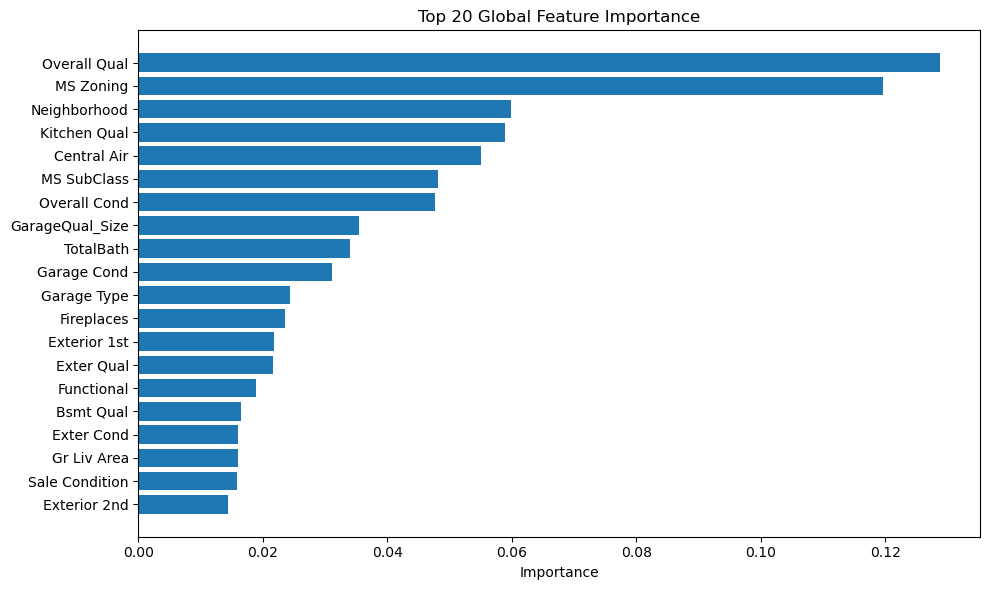

In [82]:
import pandas as pd
import matplotlib.pyplot as plt



feature_importance = best_model.feature_importances_

original_cols = ['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config',
       'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type',
       'House Style', 'Overall Qual', 'Overall Cond', 'Year Built',
       'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st',
       'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2',
       'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air',
       'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF',
       'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath',
       'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual',
       'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu',
       'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars',
       'Garage Area', 'Garage Qual', 'Garage Cond', 'Paved Drive',
       'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch',
       'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold',
       'Sale Type', 'Sale Condition', 'SalePrice', 'LogSalePrice', 'HouseAge',
       'RemodAge', 'TotalSF', 'TotalBath', 'GarageQual_Size', 'Qual_SF']
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": feature_importance
}).sort_values(by="Importance", ascending=False)

def original_feature(feature):
    for col in original_cols:
        if feature.startswith(col+'_'):
            return col
    return feature
    
importance_df['original_feature']=importance_df['Feature'].apply(original_feature)

agg_feature_importance = (
    importance_df
    .groupby("original_feature")["Importance"]
    .sum()
    .reset_index()
    .sort_values(by="Importance", ascending=False)
)

# Keep top 20 only
top_20 = agg_feature_importance.head(20)

print(top_20)

# Plot

plt.figure(figsize=(10,6))
plt.barh(top_20["original_feature"], top_20["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Global Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [83]:
!pip install shap


['Overall Qual', 'Mas Vnr Area', 'BsmtFin SF 1', '1st Flr SF', 'Gr Liv Area', 'Full Bath', 'Fireplaces', 'Garage Yr Blt', 'HouseAge', 'RemodAge', 'TotalBath', 'GarageQual_Size', 'MS SubClass', 'MS SubClass', 'MS SubClass', 'MS SubClass', 'MS SubClass', 'MS SubClass', 'MS SubClass', 'MS SubClass', 'MS SubClass', 'MS SubClass', 'MS SubClass', 'MS SubClass', 'MS SubClass', 'MS SubClass', 'MS SubClass', 'MS Zoning', 'MS Zoning', 'MS Zoning', 'MS Zoning', 'MS Zoning', 'Street', 'Lot Shape', 'Lot Shape', 'Lot Shape', 'Land Contour', 'Land Contour', 'Land Contour', 'Utilities', 'Utilities', 'Lot Config', 'Lot Config', 'Lot Config', 'Lot Config', 'Land Slope', 'Land Slope', 'Neighborhood', 'Neighborhood', 'Neighborhood', 'Neighborhood', 'Neighborhood', 'Neighborhood', 'Neighborhood', 'Neighborhood', 'Neighborhood', 'Neighborhood', 'Neighborhood', 'Neighborhood', 'Neighborhood', 'Neighborhood', 'Neighborhood', 'Neighborhood', 'Neighborhood', 'Neighborhood', 'Neighborhood', 'Neighborhood', 'Neig

C:\Users\sibus\AppData\Local\Temp\ipykernel_22900\1716591456.py:21: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  grouped_shap = shap_df.groupby(original_features, axis=1).mean()
C:\Users\sibus\AppData\Local\Temp\ipykernel_22900\1716591456.py:27: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  grouped_X = grouped_X.groupby(by=grouped_X.columns, axis=1).mean()


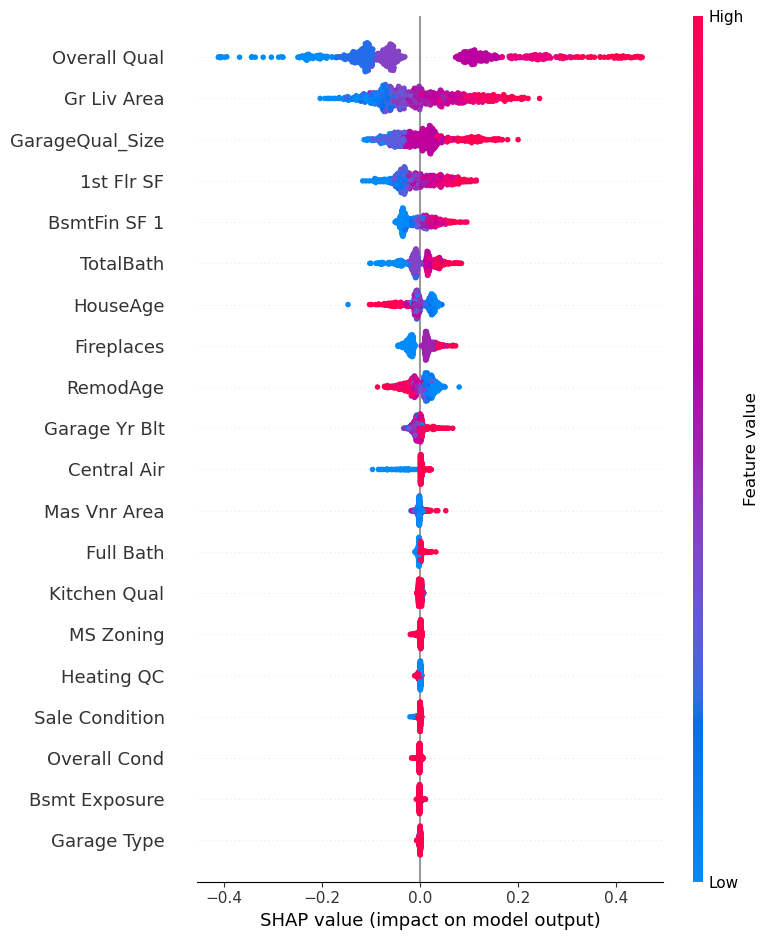

In [84]:
import shap

# Tree-based models
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

shap_df = pd.DataFrame(shap_values, columns=X_test.columns)

# Function to get original feature name
def original_feature(feature):
    for col in original_cols:
        if feature.startswith(col+'_'):
            return col
    return feature

# Map columns to original feature names
original_features = [original_feature(col) for col in shap_df.columns]
print(original_features)

# Group SHAP values by original feature (sum contributions)
grouped_shap = shap_df.groupby(original_features, axis=1).mean()


grouped_X = X_test.copy()
grouped_X = pd.DataFrame(grouped_X)
grouped_X.columns = original_features  # assign mapped names
grouped_X = grouped_X.groupby(by=grouped_X.columns, axis=1).mean()


# Convert back to numpy arrays
grouped_shap_values = grouped_shap.values
grouped_X_values = grouped_X.values

# Plot grouped summary
shap.summary_plot(grouped_shap_values, grouped_X_values, feature_names=grouped_shap.columns)
#shap.summary_plot(shap_values, X_test)

# For SVR or Linear
# explainer = shap.Explainer(best_model.predict, X_test)
# shap_values = explainer(X_test)


['Overall Qual', 'Mas Vnr Area', 'BsmtFin SF 1', '1st Flr SF', 'Gr Liv Area', 'Full Bath', 'Fireplaces', 'Garage Yr Blt', 'HouseAge', 'RemodAge', 'TotalBath', 'GarageQual_Size', 'MS SubClass', 'MS SubClass', 'MS SubClass', 'MS SubClass', 'MS SubClass', 'MS SubClass', 'MS SubClass', 'MS SubClass', 'MS SubClass', 'MS SubClass', 'MS SubClass', 'MS SubClass', 'MS SubClass', 'MS SubClass', 'MS SubClass', 'MS Zoning', 'MS Zoning', 'MS Zoning', 'MS Zoning', 'MS Zoning', 'Street', 'Lot Shape', 'Lot Shape', 'Lot Shape', 'Land Contour', 'Land Contour', 'Land Contour', 'Utilities', 'Utilities', 'Lot Config', 'Lot Config', 'Lot Config', 'Lot Config', 'Land Slope', 'Land Slope', 'Neighborhood', 'Neighborhood', 'Neighborhood', 'Neighborhood', 'Neighborhood', 'Neighborhood', 'Neighborhood', 'Neighborhood', 'Neighborhood', 'Neighborhood', 'Neighborhood', 'Neighborhood', 'Neighborhood', 'Neighborhood', 'Neighborhood', 'Neighborhood', 'Neighborhood', 'Neighborhood', 'Neighborhood', 'Neighborhood', 'Neig

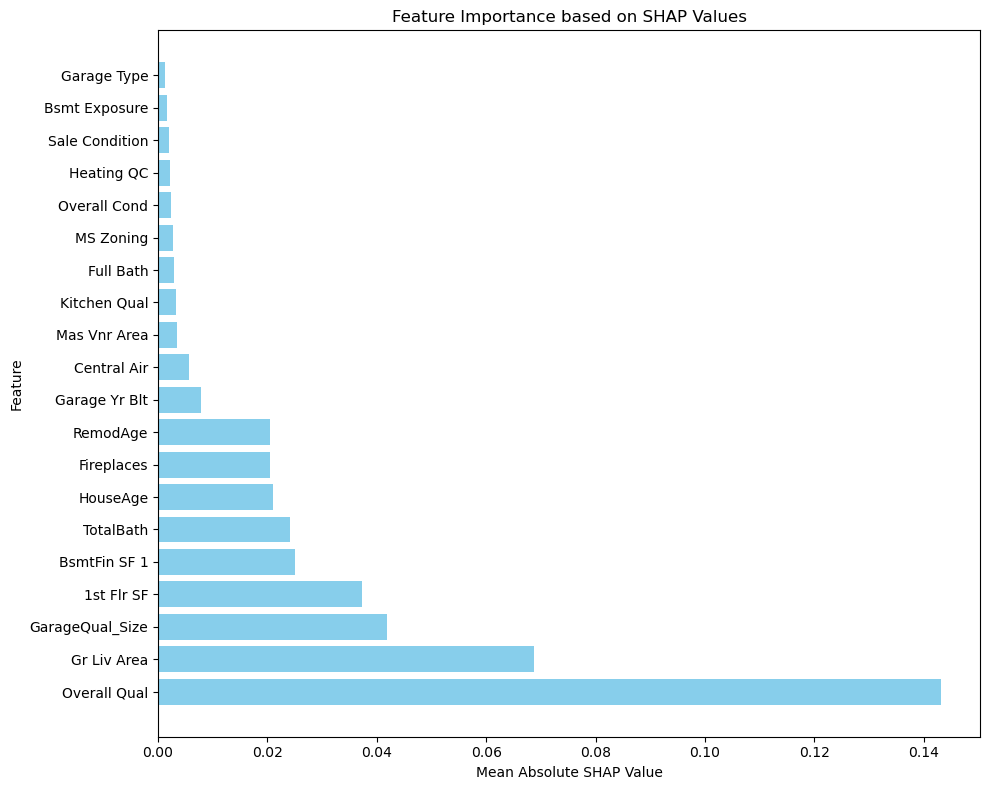

In [85]:
mean_shap_abs = np.abs(shap_values).mean(axis=0)

mapped_features = [original_feature(f) for f in X_train.columns]
print(mapped_features)

shap_feature_df_ori = pd.DataFrame({
    "feature": mapped_features ,
    "mean_shap_abs": mean_shap_abs
})



# Sort by importance
shap_ori_feature_df = shap_feature_df_ori.sort_values(
    by="mean_shap_abs",
    ascending=False
).reset_index(drop=True)

mean_shap_abs_agg = shap_ori_feature_df.groupby("feature").mean().reset_index()



mean_abs_shap_agg_sorted = mean_shap_abs_agg.sort_values(by="mean_shap_abs", ascending=False).head(20)

print(mean_abs_shap_agg_sorted)

plt.figure(figsize=(10, 8))
plt.barh(mean_abs_shap_agg_sorted['feature'], mean_abs_shap_agg_sorted['mean_shap_abs'], color='skyblue')
plt.xlabel('Mean Absolute SHAP Value')
plt.ylabel('Feature')
plt.title('Feature Importance based on SHAP Values')
plt.tight_layout()
plt.show()

In [86]:
mean_shap = np.array(shap_values).mean(axis=0)

mapped_features = [original_feature(f) for f in X_train.columns]

shap_feature_df_ori = pd.DataFrame({
    "feature": mapped_features ,
    "mean_shap": mean_shap
})

# Sort by importance
shap_ori_feature_df = shap_feature_df_ori.sort_values(
    by="mean_shap",
    ascending=False
).reset_index(drop=True)

mean_shap_agg = shap_ori_feature_df.groupby("feature").mean().reset_index().sort_values(by='mean_shap',ascending=False)

mean_shap_agg

,feature,mean_shap
26,GarageQual_Size,0.002828
45,RemodAge,0.002202
43,Overall Qual,0.001682
51,TotalBath,0.001646
8,Central Air,0.000825
32,Kitchen Qual,0.000611
17,Fireplaces,0.000478
38,MS Zoning,0.000475
19,Full Bath,0.000324
18,Foundation,0.000159


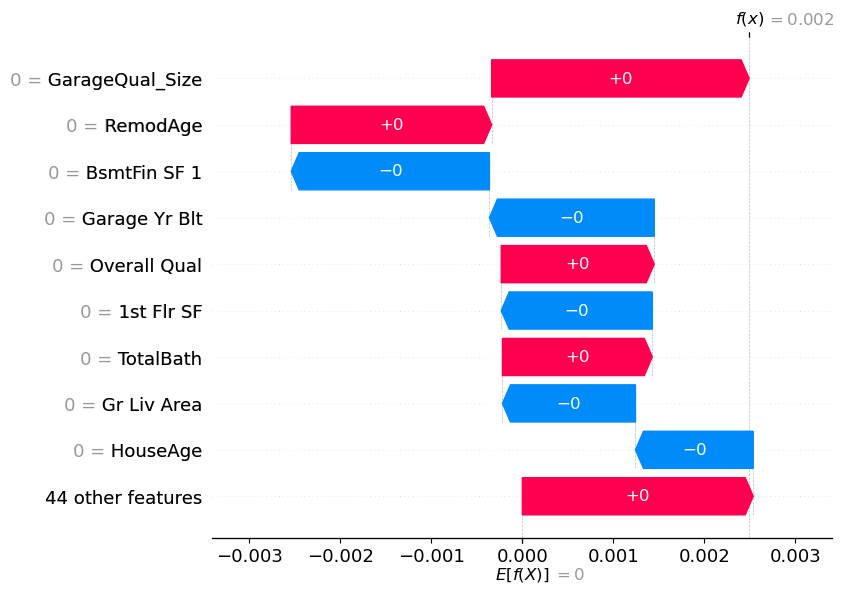

In [87]:
expl = shap.Explanation(
    values=mean_shap_agg["mean_shap"].values,  # SHAP values
    base_values=0,                                   # baseline = 0 for global importance
    data=np.zeros_like(mean_shap_agg["mean_shap"].values),  # dummy feature values
    feature_names=mean_shap_agg["feature"].values
)

shap.initjs()
shap.waterfall_plot(expl)



In [88]:
x_instance = X_test# keep as DataFrame
shap_instance = shap_values

x_instance.columns = original_features

# Group feature values by original features (mean or sum for one-hot)
x_instance_grouped = x_instance.groupby(by=x_instance.columns, axis=1).mean()

# Group SHAP values
shap_instance_df = pd.DataFrame(shap_instance, columns=original_features)
shap_instance_grouped = shap_instance_df.groupby(by=shap_instance_df.columns, axis=1).mean()




shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_instance_grouped.values[0],   # convert back to 1D array
    x_instance_grouped.values[0],      # feature values
    feature_names=x_instance_grouped.columns
)

C:\Users\sibus\AppData\Local\Temp\ipykernel_22900\732663076.py:7: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  x_instance_grouped = x_instance.groupby(by=x_instance.columns, axis=1).mean()
C:\Users\sibus\AppData\Local\Temp\ipykernel_22900\732663076.py:11: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  shap_instance_grouped = shap_instance_df.groupby(by=shap_instance_df.columns, axis=1).mean()
